# 02 — Preparazione delle sequenze per i modelli ricorrenti

Secondo notebook della pipeline. Trasforma il dataset dei cicli in finestre temporali
pronte per l'addestramento.

La fase di preprocessing del progetto si articola su due notebook: il 01 estrae e
ripulisce i cicli, il 02 costruisce gli insiemi e le sequenze. La suddivisione dei dati,
con la motivazione del criterio adottato, è nella sezione 4 di questo notebook.

Il percorso è: scelta delle variabili di ingresso, suddivisione in insiemi,
normalizzazione, costruzione delle finestre.

**Input:** `data/processed/battery_cycles.csv`, prodotto da `01_preprocessing.ipynb`.

**Output prodotti**

| percorso | contenuto |
|---|---|
| `data/processed/sequences_<configurazione>/sequence_dataset_window10.npz` | finestre temporali dei quattro insiemi |
| `results/tables/composizione_split_<configurazione>.csv` | numero di celle, cicli e finestre per insieme |
| `results/figures/02_distribuzione_target.png` | distribuzione del SoH nei quattro insiemi |

**Notebook successivo:** `03_training.ipynb`.

Ogni finestra raccoglie dieci cicli consecutivi di una stessa cella e serve a prevedere
lo State of Health del ciclo successivo.


## 1. Configurazione del progetto


In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass


def find_project_root():
    """Individua la cartella di progetto, in locale o su Google Drive."""
    candidate_paths = []
    current_path = Path.cwd().resolve()
    candidate_paths.extend([current_path] + list(current_path.parents))
    candidate_paths.extend([
        Path("/content/drive/MyDrive/SoH_Neural_Tracker"),
        Path("/content/SoH_Neural_Tracker"),
    ])

    for path in candidate_paths:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path

    raise FileNotFoundError(
        "Cartella di progetto non trovata. Serve una directory SoH_Neural_Tracker "
        "contenente almeno notebooks/ e data/."
    )


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR = RESULTS_DIR / "tables"

for folder in [DATA_PROCESSED, FIGURES_DIR, TABLES_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("Radice del progetto:", PROJECT_ROOT)


Mounted at /content/drive
Radice del progetto: /content/drive/MyDrive/SoH_Neural_Tracker


## 2. Caricamento del dataset

Il file prodotto dal preprocessing contiene tutti i cicli estratti, anche quelli marcati
come non rappresentativi. La colonna `segment_id` indica a quale tratto di cicli validi e
consecutivi appartiene ogni riga, e vale `-1` per i cicli marcati.

Se il preprocessing ha estratto anche gli indicatori dai cicli di carica, questi si
trovano sulle stesse righe e potranno essere selezionati nella sezione successiva.


In [2]:
percorso_cicli = DATA_PROCESSED / "battery_cycles.csv"
df = pd.read_csv(percorso_cicli)

# Gli indicatori di ricarica sono opzionali: se il preprocessing non li ha prodotti,
# la pipeline prosegue sui soli cicli di scarica.
INDICATORI_CARICA_DISPONIBILI = "cc_time_3v8_4v1_s" in df.columns

print("Dataset in ingresso:", percorso_cicli.name)
print("Indicatori di ricarica presenti:", INDICATORI_CARICA_DISPONIBILI)

colonne_richieste = {"battery_id", "discharge_cycle", "soh", "is_valid", "segment_id"}
mancanti = colonne_richieste - set(df.columns)
assert not mancanti, (
    f"colonne mancanti in {percorso_cicli.name}: {sorted(mancanti)}. "
    "Riesegui 01_preprocessing.ipynb."
)

print(f"Cicli caricati: {len(df)}   validi: {int(df.is_valid.sum())}")
display(df.groupby("battery_id").agg(
    n_cicli=("discharge_cycle", "size"),
    n_validi=("is_valid", "sum"),
    n_segmenti=("segment_id", lambda s: int((s >= 0).any()) and s[s >= 0].nunique()),
).T)


Dataset in ingresso: battery_cycles.csv
Indicatori di ricarica presenti: True
Cicli caricati: 1020   validi: 926


battery_id,B0005,B0006,B0007,B0018,B0029,B0030,B0031,B0032,B0042,B0043
n_cicli,168,168,168,132,40,40,40,40,112,112
n_validi,168,168,168,132,40,40,40,40,65,65
n_segmenti,1,1,1,1,1,1,1,1,3,3


## 3. Variabili di ingresso e grandezza da prevedere

Il modello deve prevedere lo State of Health del ciclo che segue la finestra.

Fra le variabili di ingresso compare anche il SoH dei cicli osservati, con il nome
`soh_feature`. È l'informazione più vicina a ciò che si vuole prevedere, e permette al
modello di collocare la finestra lungo la vita della cella.

Viene conservato a parte `soh_ultimo`, cioè il SoH dell'ultimo ciclo della finestra. È la
previsione che farebbe chi assumesse lo stato di salute invariato, quella che nel seguito
viene chiamata *persistenza*. Serve come termine di paragone: un modello è utile solo se
fa meglio di così.


In [3]:
TARGET_COLUMN = "soh"

# Copia esplicita del SoH usata come feature: tenerla distinta dal target rende
# evidente quale valore entra in ingresso e quale viene previsto.
df["soh_feature"] = df["soh"]

# I descrittori entrano nella forma riferita all'inizio vita costruita nel notebook 01:
# ciascuno diviso per il proprio valore sui primi cicli dello stesso blocco di
# protocollo, come già si fa per la capacità nel definire il SoH. In forma assoluta il
# loro livello dipende dalla cella e dal protocollo, e su una cella mai vista finirebbe
# a decine di deviazioni standard da quanto osservato in addestramento.
VARIABILI_SCARICA = [
    "soh_feature",
    "voltage_mean_rel", "voltage_min_rel", "voltage_max_rel", "voltage_std_rel",
    "temperature_mean_rise_rel", "temperature_max_rise_rel", "temperature_std_rel",
    "discharge_time_rel", "num_measurements_rel",
]

# Variabili disponibili nel dataset ma deliberatamente escluse, con la ragione.
# Vengono elencate qui perché l'esclusione è una scelta progettuale, e una scelta
# taciuta non è verificabile.
VARIABILI_ESCLUSE = {
    "capacity": "il SoH ne è il rapporto con il valore iniziale: in forma assoluta "
                "aggiunge la capacità di fabbrica della cella, che è dispersione di "
                "produzione e non stato di salute",
    "ambient_temperature": "setpoint dello sperimentatore, costante entro ogni blocco",
    "current_mean": "setpoint dello sperimentatore, costante entro ogni blocco",
    "current_min": "determinata dalla corrente impostata",
    "current_max": "determinata dalla corrente impostata",
    "current_std": "determinata dalla corrente impostata",
    "temperature_min": "coincide con la temperatura ambiente a inizio scarica",
}

VARIABILI_CARICA = [
    "cc_time_3v8_4v1_s", "charge_cc_ah", "cv_time_fraction", "cv_duration_s",
    "cc_duration_s", "charge_throughput_ah", "ica_peak_height", "ica_peak_voltage",
    "charge_temp_rise",
]

# Tre configurazioni, che corrispondono a tre domande diverse.
#
# `scarica`   il modello osserva il ciclo di scarica, in cui la capacità è misurata:
#             il SoH è quindi una funzione diretta di una variabile di ingresso, e il
#             compito si riduce a estrapolare una serie che varia lentamente.
# `carica`    il modello osserva soltanto la ricarica precedente e deve stimare la
#             capacità che verrà misurata dopo. È un vero problema di stima ed è la
#             condizione in cui opererebbe un sistema di gestione batteria.
# `completo`  entrambe, per quantificare quanto le due fonti siano complementari.
FEATURE_SETS = {
    "scarica": VARIABILI_SCARICA,
    "carica": VARIABILI_CARICA,
    "completo": VARIABILI_SCARICA + VARIABILI_CARICA,
}

# L'analisi principale del progetto usa i soli cicli di scarica: è quanto dichiarato
# nella proposta approvata. Le altre due configurazioni alimentano un esperimento
# supplementare e si attivano cambiando questa riga.
CONFIGURAZIONE = "scarica"

if not INDICATORI_CARICA_DISPONIBILI:
    FEATURE_SETS = {"scarica": VARIABILI_SCARICA}
    CONFIGURAZIONE = "scarica"

FEATURE_COLUMNS = FEATURE_SETS[CONFIGURAZIONE]

assenti = [c for c in FEATURE_COLUMNS if c not in df.columns]
assert not assenti, f"colonne assenti nel dataset: {assenti}"

print("Configurazioni disponibili:", ", ".join(FEATURE_SETS))
print(f"Configurazione attiva: {CONFIGURAZIONE} ({len(FEATURE_COLUMNS)} variabili candidate)")
print("Target:", TARGET_COLUMN)
print("\nVariabili disponibili ma escluse:")
for colonna, motivo in VARIABILI_ESCLUSE.items():
    if colonna in df.columns:
        print(f"  {colonna:22s} {motivo}")
display(df[["protocol_block", "discharge_cycle", "segment_id"] + FEATURE_COLUMNS].head(3))


Configurazioni disponibili: scarica, carica, completo
Configurazione attiva: scarica (10 variabili candidate)
Target: soh

Variabili disponibili ma escluse:
  capacity               il SoH ne è il rapporto con il valore iniziale: in forma assoluta aggiunge la capacità di fabbrica della cella, che è dispersione di produzione e non stato di salute
  ambient_temperature    setpoint dello sperimentatore, costante entro ogni blocco
  current_mean           setpoint dello sperimentatore, costante entro ogni blocco
  current_min            determinata dalla corrente impostata
  current_max            determinata dalla corrente impostata
  current_std            determinata dalla corrente impostata
  temperature_min        coincide con la temperatura ambiente a inizio scarica


,protocol_block,discharge_cycle,segment_id,soh_feature,voltage_mean_rel,voltage_min_rel,voltage_max_rel,voltage_std_rel,temperature_mean_rise_rel,temperature_max_rise_rel,temperature_std_rel,discharge_time_rel,num_measurements_rel
0,B0005_p1,0,0,1.011517,0.996467,1.007528,1.000724,1.005078,1.000000,1.011025,1.026809,1.010569,1.010256
1,B0005_p1,1,0,1.005981,0.998582,0.997787,1.000313,1.000000,1.017837,1.014482,1.009086,1.005670,1.005128
2,B0005_p1,2,0,1.000000,1.000393,1.022742,0.999934,0.969163,1.008228,1.000000,0.995169,1.000000,1.000000


## 4. Suddivisione dei dati

L'unità di suddivisione è il **blocco di protocollo** definito nel notebook 01, non la
singola finestra e non la cella.

Non la finestra, perché suddividendo le finestre a caso cicli vicini della stessa cella
finirebbero sia in addestramento sia in test: il modello avrebbe già visto la traiettoria
da completare, e le prestazioni misurate risulterebbero più alte di quelle reali.

Non la cella, perché due celle del dataset cambiano protocollo a metà della propria vita:
B0042 e B0043 sono ciclate per quarantuno cicli a 22 °C e 2 A e per i successivi
settantuno a 4 °C e circa 3 A. Assegnarle per intero a un insieme significherebbe
mescolarvi due condizioni sperimentali diverse, e in particolare chiamare «fuori
distribuzione» anche la loro prima metà, che il protocollo di addestramento lo condivide.

Ne risulta la suddivisione seguente.

| insieme | blocchi | protocollo |
|---|---|---|
| addestramento | B0005, B0006 | 24 °C, 2 A |
| validazione | B0007 | 24 °C, 2 A |
| test in distribuzione | B0018, prima metà di B0042 e B0043 | 24 e 22 °C, 2 A |
| test fuori distribuzione | B0029–B0032, seconda metà di B0042 e B0043 | 43 °C 4 A, 4 °C 3 A |

Il test fuori distribuzione contiene così due condizioni diverse e opposte: quattro celle
più calde e più sollecitate, e due tratti più freddi. E poiché B0042 e B0043 compaiono in
entrambi i test, il confronto fra i due avviene in parte **sulle stesse celle**: la
differenza di prestazioni misura allora il cambio di protocollo, e non la differenza fra
un esemplare e un altro.

**Due limiti da dichiarare.** Il primo: nel dataset temperatura e corrente cambiano
sempre insieme, quindi nessuna perdita di prestazioni è attribuibile alla sola
temperatura; ciò che si misura è l'effetto del cambio di protocollo nel suo complesso.
Il secondo: i tratti a 4 °C arrivano dopo quelli a 22 °C sulla stessa cella, e sono
quindi anche più avanzati nella vita della batteria.


In [4]:
# Blocchi di protocollo, non celle: `B0042_p1` è il tratto a 22 °C della cella B0042,
# `B0042_p2` quello a 4 °C. Una cella a protocollo costante ha un solo blocco.
SPLIT = {
    "train":      ["B0005_p1", "B0006_p1"],
    "validation": ["B0007_p1"],
    "test_id":    ["B0018_p1", "B0042_p1", "B0043_p1"],
    "test_ood":   ["B0029_p1", "B0030_p1", "B0031_p1", "B0032_p1",
                   "B0042_p2", "B0043_p2"],
}

assegnati = [b for blocchi in SPLIT.values() for b in blocchi]
assert len(assegnati) == len(set(assegnati)), "un blocco compare in più insiemi"
mancanti = set(df.protocol_block.unique()) - set(assegnati)
assert not mancanti, f"blocchi non assegnati ad alcun insieme: {sorted(mancanti)}"

parti = {nome: df[df.protocol_block.isin(blocchi)].copy() for nome, blocchi in SPLIT.items()}

composizione = pd.DataFrame([
    {
        "insieme": nome,
        "blocchi": ", ".join(SPLIT[nome]),
        "n_blocchi": len(SPLIT[nome]),
        "n_cicli": len(parte),
        "n_validi": int(parte.is_valid.sum()),
        "ambiente_c": round(float(parte[parte.is_valid].ambient_temperature.median()), 1),
        "corrente_a": round(float(parte[parte.is_valid].current_mean.abs().median()), 2),
        "durata_s": round(float(parte[parte.is_valid].discharge_time.median()), 0),
    }
    for nome, parte in parti.items()
])
display(composizione)

# Addestramento, validazione e test in distribuzione devono condividere il protocollo:
# se differissero, il test in distribuzione non misurerebbe ciò che il suo nome dichiara.
riferimento = composizione[composizione.insieme != "test_ood"]
assert riferimento.corrente_a.max() - riferimento.corrente_a.min() < 0.5, (
    "gli insiemi di riferimento non condividono la corrente di scarica"
)
assert riferimento.ambiente_c.max() - riferimento.ambiente_c.min() <= 5.0, (
    "gli insiemi di riferimento non condividono la temperatura ambiente"
)

# Le celle che compaiono sia in distribuzione sia fuori: su di esse il confronto fra i
# due test è a parità di esemplare.
celle = {nome: {b.split("_p")[0] for b in blocchi} for nome, blocchi in SPLIT.items()}
condivise = sorted(celle["test_id"] & celle["test_ood"])
print(f"\nGruppo di riferimento: {riferimento.corrente_a.median():.1f} A, "
      f"{riferimento.ambiente_c.median():.0f} °C")
print("Celle presenti in entrambi i test, a protocollo diverso:",
      ", ".join(condivise) if condivise else "nessuna")


,insieme,blocchi,n_blocchi,n_cicli,n_validi,ambiente_c,corrente_a,durata_s
0,train,"B0005_p1, B0006_p1",2,336,336,24.0,1.79,3086.0
1,validation,B0007_p1,1,168,168,24.0,1.90,3086.0
2,test_id,"B0018_p1, B0042_p1, B0043_p1",3,214,212,24.0,1.87,3030.0
3,test_ood,"B0029_p1, B0030_p1, B0031_p1, B0032_p1, B0042_...",6,302,210,43.0,3.85,1637.0



Gruppo di riferimento: 1.9 A, 24 °C
Celle presenti in entrambi i test, a protocollo diverso: B0042, B0043


## 5. Normalizzazione

Media e deviazione standard sono calcolate sui soli cicli validi delle celle di
addestramento. La stessa trasformazione viene poi applicata agli altri insiemi.

Non tutte le variabili candidate arrivano al modello: due categorie vengono escluse, per
ragioni diverse.

**Parametri del protocollo.** La corrente di scarica e la temperatura ambiente sono scelte
dello sperimentatore, non proprietà della cella. Dentro una stessa batteria non cambiano
mai, e da un gruppo all'altro cambiano tutte insieme. In addestramento assumono un valore
soltanto, quindi il modello non ha modo di imparare cosa accade quando quel valore è
diverso. Lo stesso vale per media, minimo, massimo e deviazione standard della corrente
misurata, il cui livello è fissato dalla corrente impostata.

**Variabili che in addestramento variano troppo poco.** La normalizzazione esprime ogni
variabile in multipli della deviazione standard calcolata sull'addestramento. Se quella
deviazione è piccola rispetto a quanto la grandezza varia davvero, i valori delle celle di
test finiscono a decine di deviazioni standard dall'origine, in una zona che il modello
non ha mai incontrato mentre imparava. Vengono perciò escluse le variabili la cui
deviazione standard in addestramento copre meno del cinque per cento di quella osservata
su tutte le celle.

**Un ultimo accorgimento: i valori normalizzati vengono limitati a cinque deviazioni
standard.** Il limite è una proprietà del solo insieme di addestramento e non guarda ai
dati di test: oltre le cinque deviazioni standard la rete non ha praticamente osservato
nulla, e la differenza fra otto e quaranta non è informazione che possa aver imparato a
usare. Limitare mantiene il valore estremo — resta il più grande possibile — evitando che
la sua scala domini l'ingresso e produca uscite prive di senso fisico. È l'unica
alternativa allo scartare del tutto la variabile, e conserva più informazione.

Il SoH osservato fa eccezione e resta nella scala originale. È già compreso fra 0 e 1 ed è
confrontabile direttamente con la grandezza da prevedere: normalizzarlo non porterebbe
alcun vantaggio numerico e ne renderebbe meno immediata la lettura.


In [5]:
COLONNE_NON_NORMALIZZATE = ["soh_feature"]

train_valido = parti["train"][parti["train"].is_valid]

# Quota minima della variabilità complessiva che l'addestramento deve coprire perché
# una variabile sia considerata apprendibile.
COPERTURA_MINIMA = 0.05

# Parametri del protocollo di scarica e grandezze che ne ereditano il livello: la
# corrente è un setpoint, e media, minimo, massimo e deviazione standard della corrente
# misurata ne sono determinati.
DESCRITTORI_PROTOCOLLO = [
    "ambient_temperature",
    "current_mean", "current_min", "current_max", "current_std",
]

normalizzabili = [c for c in FEATURE_COLUMNS
                  if c not in COLONNE_NON_NORMALIZZATE
                  and c not in DESCRITTORI_PROTOCOLLO]
esclusi_protocollo = [c for c in FEATURE_COLUMNS if c in DESCRITTORI_PROTOCOLLO]
validi_ovunque = df[df.is_valid]

diagnostica = pd.DataFrame({
    "sd_train": train_valido[normalizzabili].std(ddof=0),
    "sd_dataset": validi_ovunque[normalizzabili].std(ddof=0),
})
diagnostica["copertura"] = (
    diagnostica.sd_train / diagnostica.sd_dataset.replace(0.0, np.nan)
)

# Una variabile è scartata se non varia affatto in addestramento, oppure se vi varia
# molto meno di quanto vari nel dataset complessivo.
non_apprendibili = diagnostica[
    (diagnostica.sd_train <= 1e-12) | (diagnostica.copertura < COPERTURA_MINIMA)
].index.tolist()

da_normalizzare = [c for c in normalizzabili if c not in non_apprendibili]
assert da_normalizzare, "nessuna variabile supera il criterio di apprendibilità"

# Oltre questo scostamento la normalizzazione viene troncata: il valore resta il
# massimo osservabile, ma non arriva alla rete in una scala che non ha mai visto.
LIMITE_SCOSTAMENTO = 5.0

scaler = StandardScaler().fit(train_valido[da_normalizzare])
FEATURE_USATE = da_normalizzare + COLONNE_NON_NORMALIZZATE


def normalizza(parte):
    scalata = parte.copy()
    scalata[da_normalizzare] = np.clip(
        scaler.transform(parte[da_normalizzare]),
        -LIMITE_SCOSTAMENTO, LIMITE_SCOSTAMENTO)
    return scalata


parti_scalate = {nome: normalizza(parte) for nome, parte in parti.items()}

# Alcuni indicatori non sono definiti su ogni ciclo: il tempo di carica a corrente
# costante, ad esempio, richiede che la cella attraversi l'intera finestra di
# tensione. I cicli in cui manca una delle variabili effettivamente usate vengono
# marcati come non validi, anziché riempiti con un valore convenzionale che il
# modello leggerebbe come una misura reale.
righe_incomplete = df[FEATURE_USATE].isna().any(axis=1) & df.is_valid
if righe_incomplete.any():
    print(f"Cicli scartati per valori mancanti: {int(righe_incomplete.sum())} "
          f"su {int(df.is_valid.sum())} validi\n")
    df.loc[righe_incomplete, "is_valid"] = False
    parti = {nome: df[df.protocol_block.isin(blocchi)].copy()
             for nome, blocchi in SPLIT.items()}
    train_valido = parti["train"][parti["train"].is_valid]
    parti_scalate = {nome: normalizza(parte) for nome, parte in parti.items()}

if esclusi_protocollo:
    print("Variabili escluse perché descrittori del protocollo sperimentale:")
    for colonna in esclusi_protocollo:
        per_blocco = validi_ovunque.groupby("protocol_block")[colonna].median()
        print(f"  {colonna:22s} valori per blocco: "
              f"{sorted(per_blocco.round(2).unique())}")
    print()

if non_apprendibili:
    print("Variabili escluse per variabilità insufficiente in addestramento:\n")
    display(diagnostica.loc[non_apprendibili].sort_values("copertura").round(6))

print(f"Variabili normalizzate:           {len(da_normalizzare)}")
print(f"Variabili in scala originale:     {len(COLONNE_NON_NORMALIZZATE)}")
print(f"Variabili in ingresso al modello: {len(FEATURE_USATE)} su {len(FEATURE_COLUMNS)} candidate")


Variabili normalizzate:           9
Variabili in scala originale:     1
Variabili in ingresso al modello: 10 su 10 candidate


### Controllo degli scostamenti

Anche fra le variabili ammesse, quelle delle celle fuori distribuzione possono trovarsi
lontano dai valori visti in addestramento. È lo scostamento che la terza domanda di ricerca
vuole misurare: va quantificato, non eliminato.

La tabella riporta lo scostamento di ciascun insieme prima della limitazione, così che
resti visibile quanto le condizioni operative differiscano davvero. La colonna
`quota_limitata` dice quale frazione dei valori è stata troncata: se fosse alta, la
variabile andrebbe esclusa invece che limitata, perché su di essa il modello riceverebbe
quasi ovunque lo stesso valore.


In [6]:
QUOTA_LIMITATA_MASSIMA = 0.05   # oltre questa quota la variabile va esclusa, non limitata

intervalli, responsabili = [], []
for nome, parte in parti.items():
    valida = parte[parte.is_valid]
    grezzo = scaler.transform(valida[da_normalizzare])

    intervalli.append({
        "insieme": nome,
        "scostamento_massimo": float(np.abs(grezzo).max()),
        "quota_limitata": float(np.mean(np.abs(grezzo) > LIMITE_SCOSTAMENTO)),
    })

    for j, colonna in enumerate(da_normalizzare):
        z_max = float(np.abs(grezzo[:, j]).max())
        if z_max > LIMITE_SCOSTAMENTO:
            responsabili.append({
                "insieme": nome,
                "variabile": colonna,
                "scostamento_massimo": z_max,
                "quota_limitata": float(np.mean(np.abs(grezzo[:, j]) > LIMITE_SCOSTAMENTO)),
                "media_train": float(train_valido[colonna].mean()),
                "media_insieme": float(valida[colonna].mean()),
            })

intervalli = pd.DataFrame(intervalli)
display(intervalli.round(4))

if responsabili:
    responsabili = pd.DataFrame(responsabili).sort_values(
        "scostamento_massimo", ascending=False)
    print(f"Variabili che superano le {LIMITE_SCOSTAMENTO:.0f} deviazioni standard:\n")
    display(responsabili.round(4))
    print("Lo scostamento è atteso sui blocchi fuori distribuzione ed è la grandezza "
          "che la terza domanda di ricerca vuole misurare.")
else:
    print(f"Tutti gli insiemi restano entro {LIMITE_SCOSTAMENTO:.0f} deviazioni standard.")

troppo_limitati = intervalli[intervalli.quota_limitata > QUOTA_LIMITATA_MASSIMA]
assert troppo_limitati.empty, (
    f"negli insiemi {list(troppo_limitati.insieme)} più del "
    f"{QUOTA_LIMITATA_MASSIMA:.0%} dei valori viene troncato: le variabili responsabili "
    f"non sono confrontabili con l'addestramento e vanno escluse, non limitate"
)


,insieme,scostamento_massimo,quota_limitata
0,train,6.8760,0.0007
1,validation,5.1895,0.0013
2,test_id,3.4052,0.0000
3,test_ood,18.8892,0.0074


Variabili che superano le 5 deviazioni standard:



,insieme,variabile,scostamento_massimo,quota_limitata,media_train,media_insieme
3,test_ood,voltage_max_rel,18.8892,0.0667,1.0013,0.9987
0,train,voltage_max_rel,6.8760,0.0060,1.0013,1.0013
1,validation,voltage_min_rel,5.1895,0.0060,1.0057,1.0270
2,validation,voltage_max_rel,5.1733,0.0060,1.0013,1.0005


Lo scostamento è atteso sui blocchi fuori distribuzione ed è la grandezza che la terza domanda di ricerca vuole misurare.


## 6. Costruzione delle finestre temporali

Ogni esempio è composto da `WINDOW_SIZE` cicli consecutivi e dal SoH del ciclo
successivo:

$$X_i = \big[\mathbf{x}_{t}, \dots, \mathbf{x}_{t+w-1}\big], \qquad
y_i = \mathrm{SoH}(t+w)$$

Ogni finestra resta dentro un tratto di cicli consecutivi e validi appartenenti allo
stesso blocco di protocollo. Non attraversa mai un ciclo scartato, né il confine fra due
celle, né un cambio di condizioni sperimentali: solo così la sequenza descrive
un'evoluzione realmente avvenuta a condizioni costanti.

I tratti vengono ricavati dalla numerazione dei cicli nel momento stesso in cui le finestre
vengono costruite, e non letti da una colonna calcolata in precedenza. La contiguità è una
condizione necessaria alla correttezza delle sequenze: verificarla dove le sequenze nascono
evita che una selezione applicata a valle la invalidi senza che ci si accorga.


In [7]:
WINDOW_SIZE = 10
PREDICTION_HORIZON = 1


def costruisci_finestre(df_scalato, feature_columns, target_column=TARGET_COLUMN,
                        window_size=WINDOW_SIZE, horizon=PREDICTION_HORIZON):
    """Costruisce le finestre temporali restando dentro i tratti contigui.

    I tratti vengono ricavati qui dalla numerazione dei cicli validi, e non letti da
    una colonna calcolata altrove: la contiguità è una condizione necessaria alla
    correttezza delle sequenze, e va verificata nel punto in cui le sequenze nascono.

    Restituisce, oltre a X e y, il SoH dell'ultimo ciclo osservato di ogni finestra e
    gli identificativi necessari a ricondurre ciascuna previsione alla cella e al
    ciclo di provenienza.
    """
    X, y, soh_ultimo, blocchi, cicli_target = [], [], [], [], []

    validi = df_scalato[df_scalato.is_valid]

    for blocco, gruppo in validi.groupby("protocol_block"):
        gruppo = gruppo.sort_values("discharge_cycle")
        numerazione = gruppo["discharge_cycle"].to_numpy()

        # Un salto nella numerazione apre un tratto nuovo. Il raggruppamento per blocco
        # garantisce già che il protocollo non cambi dentro il tratto.
        apre_tratto = np.ones(len(gruppo), dtype=bool)
        apre_tratto[1:] = np.diff(numerazione) != 1

        for _, tratto in gruppo.groupby(np.cumsum(apre_tratto)):
            valori = tratto[feature_columns].to_numpy()
            target = tratto[target_column].to_numpy()
            soh = tratto["soh"].to_numpy()
            cicli = tratto["discharge_cycle"].to_numpy()

            for i in range(len(tratto) - window_size - horizon + 1):
                fine_finestra = i + window_size - 1
                indice_target = fine_finestra + horizon

                X.append(valori[i:i + window_size])
                y.append(target[indice_target])
                soh_ultimo.append(soh[fine_finestra])
                blocchi.append(blocco)
                cicli_target.append(cicli[indice_target])

    blocchi = np.asarray(blocchi)
    return {
        "X": np.asarray(X, dtype="float32"),
        "y": np.asarray(y, dtype="float32"),
        "soh_ultimo": np.asarray(soh_ultimo, dtype="float32"),
        "protocol_block": blocchi,
        "battery_id": np.asarray([b.split("_p")[0] for b in blocchi]),
        "target_cycle": np.asarray(cicli_target),
    }


sequenze = {nome: costruisci_finestre(scalata, FEATURE_USATE)
            for nome, scalata in parti_scalate.items()}

for nome, s in sequenze.items():
    print(f"{nome:12s} X {str(s['X'].shape):18s} y {s['y'].shape}")


train        X (316, 10, 10)      y (316,)
validation   X (158, 10, 10)      y (158,)
test_id      X (172, 10, 10)      y (172,)
test_ood     X (150, 10, 10)      y (150,)


### Controllo delle finestre

Le proprietà su cui si appoggiano tutti i risultati successivi vengono verificate qui. Se
una di esse non valesse, il notebook proseguirebbe senza segnalare nulla e le metriche
finali sembrerebbero normali: per questo il controllo è esplicito.


In [8]:
mappa_validi = {(r.protocol_block, r.discharge_cycle): r.is_valid
                for r in df.itertuples()}

for nome, s in sequenze.items():
    assert len(s["X"]) == len(s["y"]) == len(s["protocol_block"]) == len(s["target_cycle"]), \
        f"{nome}: lunghezze incoerenti fra X, y e metadati"

    attesi = set(SPLIT[nome])
    assert set(s["protocol_block"]) <= attesi, \
        f"{nome}: contiene finestre di blocchi non assegnati a questo insieme"

    # Ogni finestra deve coprire cicli consecutivi e validi dello stesso blocco.
    for blocco, ciclo_target in zip(s["protocol_block"], s["target_cycle"]):
        primo = ciclo_target - WINDOW_SIZE - PREDICTION_HORIZON + 1
        for ciclo in range(primo, ciclo_target + 1):
            assert mappa_validi.get((blocco, ciclo), False), \
                f"{nome}: la finestra su {blocco} include il ciclo non valido {ciclo}"

    assert np.all(np.isfinite(s["soh_ultimo"])), f"{nome}: soh_ultimo contiene valori non finiti"
    assert np.all(np.abs(s["X"]) <= LIMITE_SCOSTAMENTO + 1e-6), \
        f"{nome}: ingressi oltre il limite di scostamento"

# Nessuna finestra di addestramento può provenire da una cella usata in test: la
# suddivisione è per blocco, ma le celle di addestramento non devono comparire altrove.
celle_train = {b.split("_p")[0] for b in SPLIT["train"]}
for nome in ["validation", "test_id", "test_ood"]:
    condivise = celle_train & {b.split("_p")[0] for b in SPLIT[nome]}
    assert not condivise, f"{nome} contiene celle usate in addestramento: {condivise}"

print("Verifiche superate:")
print("  - nessuna finestra attraversa blocchi diversi o cicli non validi")
print("  - ogni finestra copre cicli consecutivi a protocollo costante")
print("  - nessuna cella di addestramento compare negli insiemi di valutazione")
print("  - il riferimento di persistenza è definito per ogni finestra")


Verifiche superate:
  - nessuna finestra attraversa blocchi diversi o cicli non validi
  - ogni finestra copre cicli consecutivi a protocollo costante
  - nessuna cella di addestramento compare negli insiemi di valutazione
  - il riferimento di persistenza è definito per ogni finestra


## 7. Distribuzione della grandezza da prevedere

Il grafico mostra come si distribuisce il SoH da prevedere nei quattro insiemi. Le celle
fuori distribuzione sono osservate per meno cicli e coprono quindi un intervallo di degrado
più stretto: è una differenza di cui tenere conto nel confronto fra le metriche.

La tabella riporta l'errore della previsione di persistenza, quella che assume il SoH
invariato rispetto all'ultimo ciclo osservato. È il valore da battere: un modello che non
lo migliora non aggiunge nulla.


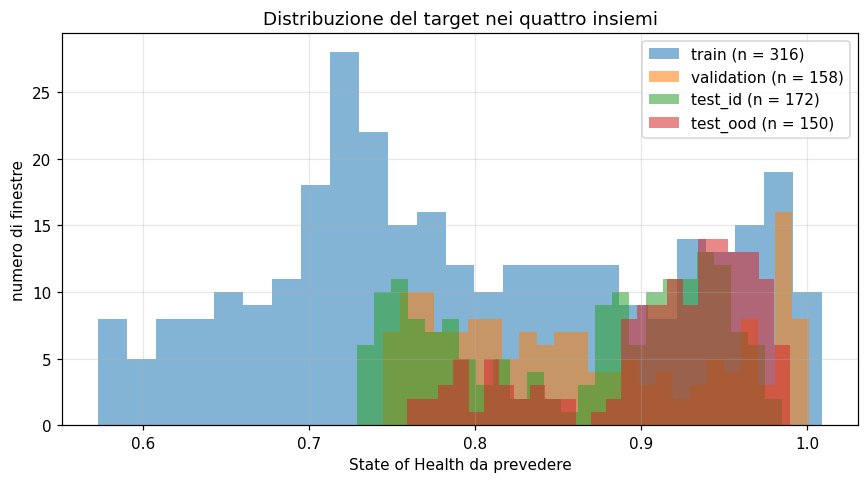

In [9]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for nome, s in sequenze.items():
    ax.hist(s["y"], bins=25, alpha=0.55, label=f"{nome} (n = {len(s['y'])})")

ax.set_xlabel("State of Health da prevedere")
ax.set_ylabel("numero di finestre")
ax.set_title("Distribuzione del target nei quattro insiemi")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_distribuzione_target.png", dpi=200, bbox_inches="tight")
plt.show()


In [10]:
riferimento = []
for nome, s in sequenze.items():
    errore = s["soh_ultimo"] - s["y"]
    riferimento.append({
        "insieme": nome,
        "n_finestre": len(s["y"]),
        "target_min": float(s["y"].min()),
        "target_max": float(s["y"].max()),
        "persistenza_MAE": float(np.mean(np.abs(errore))),
        "persistenza_RMSE": float(np.sqrt(np.mean(errore ** 2))),
    })

riferimento = pd.DataFrame(riferimento)
display(riferimento.round(5))

composizione = composizione.merge(
    riferimento[["insieme", "n_finestre", "persistenza_RMSE"]], on="insieme"
)
display(composizione)


,insieme,n_finestre,target_min,target_max,persistenza_MAE,persistenza_RMSE
0,train,316,0.57309,1.00896,0.00589,0.00989
1,validation,158,0.74466,1.00149,0.00381,0.00675
2,test_id,172,0.72899,0.98506,0.00685,0.01103
3,test_ood,150,0.75931,0.98957,0.00673,0.00804


,insieme,blocchi,n_blocchi,n_cicli,n_validi,ambiente_c,corrente_a,durata_s,n_finestre,persistenza_RMSE
0,train,"B0005_p1, B0006_p1",2,336,336,24.0,1.79,3086.0,316,0.009892
1,validation,B0007_p1,1,168,168,24.0,1.90,3086.0,158,0.006752
2,test_id,"B0018_p1, B0042_p1, B0043_p1",3,214,212,24.0,1.87,3030.0,172,0.011026
3,test_ood,"B0029_p1, B0030_p1, B0031_p1, B0032_p1, B0042_...",6,302,210,43.0,3.85,1637.0,150,0.008043


## 8. Salvataggio

Le finestre vengono salvate in formato compresso, insieme alle informazioni necessarie a
interpretarle: nomi delle variabili usate, ampiezza della finestra, orizzonte di previsione
e composizione degli insiemi.


In [11]:
# Ogni versione del dataset in una sottocartella propria, come richiesto quando il
# preprocessing ne produce più di una.
cartella_sequenze = DATA_PROCESSED / f"sequences_{CONFIGURAZIONE}"
cartella_sequenze.mkdir(parents=True, exist_ok=True)
percorso_sequenze = cartella_sequenze / f"sequence_dataset_window{WINDOW_SIZE}.npz"

da_salvare = {}
for nome, s in sequenze.items():
    for chiave, valore in s.items():
        da_salvare[f"{nome}__{chiave}"] = valore

da_salvare["configurazione"] = CONFIGURAZIONE
da_salvare["feature_names"] = np.array(FEATURE_USATE)
da_salvare["feature_escluse_protocollo"] = np.array(esclusi_protocollo)
da_salvare["feature_escluse_variabilita"] = np.array(non_apprendibili)
da_salvare["window_size"] = WINDOW_SIZE
da_salvare["prediction_horizon"] = PREDICTION_HORIZON
da_salvare["limite_scostamento"] = LIMITE_SCOSTAMENTO
for nome, blocchi in SPLIT.items():
    da_salvare[f"split__{nome}"] = np.array(blocchi)

np.savez_compressed(percorso_sequenze, **da_salvare)
composizione.to_csv(cartella_sequenze / "composizione_split.csv", index=False)
composizione.to_csv(TABLES_DIR / f"composizione_split_{CONFIGURAZIONE}.csv", index=False)

print("File salvati:")
print("  ", percorso_sequenze.relative_to(PROJECT_ROOT),
      f"({percorso_sequenze.stat().st_size / 1e6:.2f} MB)")
print("  ", (TABLES_DIR / f"composizione_split_{CONFIGURAZIONE}.csv").relative_to(PROJECT_ROOT))

print(f"\nFinestre totali: {sum(len(s['y']) for s in sequenze.values())}")
print(f"Variabili in ingresso: {len(FEATURE_USATE)}")
print("\nNotebook successivo: 03_training.ipynb")


File salvati:
   data/processed/sequences_scarica/sequence_dataset_window10.npz (0.05 MB)
   results/tables/composizione_split_scarica.csv

Finestre totali: 796
Variabili in ingresso: 10

Notebook successivo: 03_training.ipynb
